# 超參數調校(Hyperparameter tuning)

## 安裝套件

In [1]:
!pip install ray

## 載入套件

In [2]:
import os
import tempfile

import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.nn import functional as F
from ray import tune
from ray.tune import Checkpoint
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## 判斷是否有GPU

In [3]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 建立模型結構

In [4]:
class ConvNet(nn.Module):
    def __init__(self) -> None:
        super(ConvNet, self).__init__()
        # In this example, we don't change the model architecture
        # due to simplicity.
        self.conv1 = nn.Conv2d(1, 3, kernel_size=3)
        self.fc = nn.Linear(192, 10)

    def forward(self, x: torch.Tensor):
        x = F.relu(F.max_pool2d(self.conv1(x), 3))
        x = x.view(-1, 192)
        x = self.fc(x)
        return F.log_softmax(x, dim=1)

## 定義模型訓練及測試函數

In [5]:
# 訓練週期
EPOCH_SIZE = 5


# 定義模型訓練函數
def train(model: nn.Module, optimizer: optim.Optimizer, train_loader: DataLoader) -> None:
    model.train()
    data: torch.Tensor
    target: torch.Tensor
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output: torch.Tensor = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()


# 定義模型測試函數
def test(model: nn.Module, data_loader: DataLoader) -> float:
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        data: torch.Tensor
        target: torch.Tensor
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            outputs: torch.Tensor = model(data)
            # 準確數計算
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    return correct / total

## 定義特徵縮放函數

In [6]:
mnist_transforms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

## 定義資料載入及模型訓練函數

In [7]:
# Ray Tune 會將每個試驗的工作目錄切換到暫存目錄，故資料路徑須使用絕對路徑
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('src')), "data")

In [8]:
def train_mnist(config):
    # 載入 MNIST 手寫阿拉伯數字資料
    train_loader = DataLoader(
        datasets.MNIST(DATA_DIR, train=True, transform=mnist_transforms), batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        datasets.MNIST(DATA_DIR, train=False, transform=mnist_transforms), batch_size=64, shuffle=True
    )

    # 建立模型
    model = ConvNet().to(device)

    # 優化器，使用組態參數
    optimizer = optim.SGD(model.parameters(), lr=config["lr"], momentum=config["momentum"])
    # 訓練 10 週期
    for i in range(10):
        train(model, optimizer, train_loader)
        # 測試
        acc = test(model, test_loader)

        # 每 5 週期存檔一次，並以 Checkpoint 物件回傳，Ray Tune 才會將檔案同步保存到永久儲存位置
        if i % 5 == 0:
            with tempfile.TemporaryDirectory() as tmpdir:
                torch.save(model.state_dict(), os.path.join(tmpdir, "model.pth"))
                # 訓練結果交回給 Ray Tune
                tune.report({"mean_accuracy": acc}, checkpoint=Checkpoint.from_directory(tmpdir))
        else:
            # 訓練結果交回給 Ray Tune
            tune.report({"mean_accuracy": acc})

## 參數調校

In [9]:
# 參數組合
search_space = {
    # "lr": tune.sample_from(lambda spec: 10**(-10 * np.random.rand())),
    "lr": tune.grid_search([0.01, 0.1, 0.5]),  # 每一選項都要測試
    "momentum": tune.uniform(0.1, 0.9),  # 均勻分配抽樣
}

# 加下一行，採分散式處理
# ray.init(address="auto")

# 執行參數調校
# analysis = tune.run(train_mnist, config=search_space, resources_per_trial={'gpu': 1})
analysis = tune.run(train_mnist, config=search_space)

2026-08-07 13:57:50,150	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-07 13:57:50,599	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2026-08-07 13:57:50,600	INFO tune.py:621 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


Trial name,mean_accuracy
train_mnist_8a880_00000,0.967
train_mnist_8a880_00001,0.9492
train_mnist_8a880_00002,0.0974


(train_mnist pid=20959) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/rikenmi/ray_results/train_mnist_2026-08-07_13-57-50/train_mnist_8a880_00002_2_lr=0.5000,momentum=0.6918_2026-08-07_13-57-50/checkpoint_000000)
(train_mnist pid=20961) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/rikenmi/ray_results/train_mnist_2026-08-07_13-57-50/train_mnist_8a880_00000_0_lr=0.0100,momentum=0.7567_2026-08-07_13-57-50/checkpoint_000001) [repeated 3x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
2026-08-07 13:58:47,424	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/Users/rikenmi/ray_results/train_mnist_2026-08-07_13-57-50' in 0.0040s.
2026-08-07 13:58:47,426	INFO tune.py:1039 -- Total run time: 56.83 seconds (56.80 s

## 取得實驗的參數

In [10]:
for i in analysis.get_all_configs().keys():
    print(analysis.get_all_configs()[i])

{'lr': 0.01, 'momentum': 0.7567006683047287}
{'lr': 0.1, 'momentum': 0.7502873795642558}
{'lr': 0.5, 'momentum': 0.6917754273190556}


## 對訓練過程的準確率繪圖

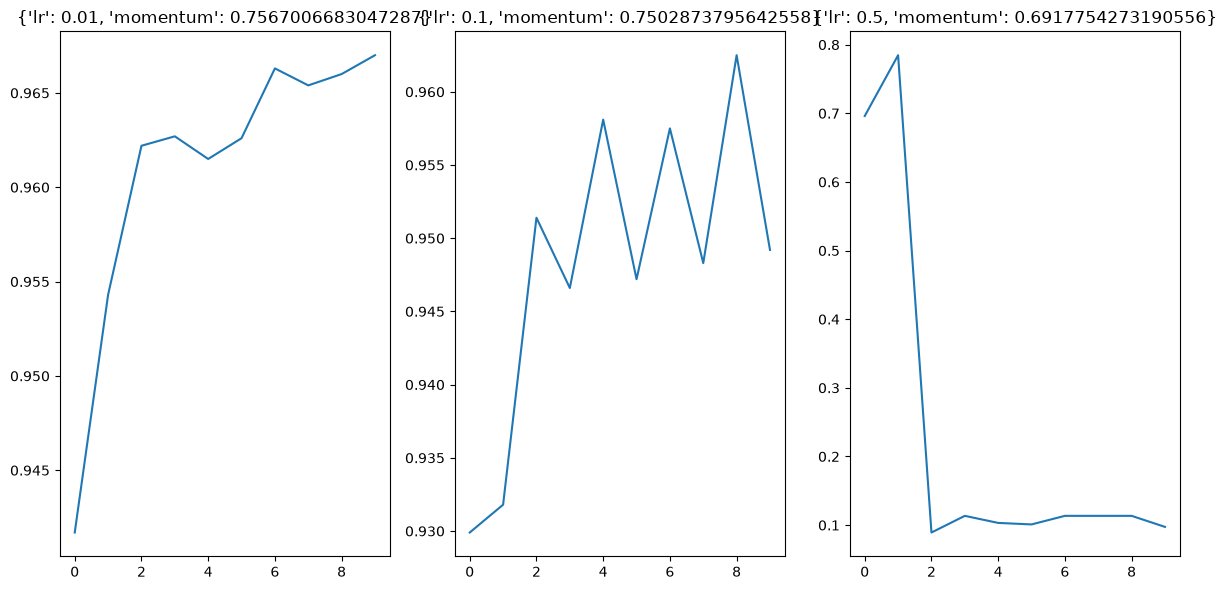

In [11]:
# 取得實驗的參數
config_list = []
for i in analysis.get_all_configs().keys():
    config_list.append(analysis.get_all_configs()[i])

# 繪圖
plt.figure(figsize=(12, 6))
dfs = analysis.trial_dataframes
for i, d in enumerate(dfs.values()):
    plt.subplot(1, 3, i + 1)
    plt.title(config_list[i])
    d.mean_accuracy.plot()
plt.tight_layout()
plt.show()

## 顯示詳細調校內容

In [12]:
for i in dfs.keys():
    parameters = i.split("\\")[-1]
    print(f'{parameters}\n', dfs[i][['mean_accuracy', 'time_total_s']])

8a880_00000
    mean_accuracy  time_total_s
0         0.9417      5.802138
1         0.9543     11.291377
2         0.9622     16.585590
3         0.9627     21.851333
4         0.9615     27.217203
5         0.9626     32.769703
6         0.9663     38.354081
7         0.9654     43.547709
8         0.9660     48.790683
9         0.9670     53.951277
8a880_00001
    mean_accuracy  time_total_s
0         0.9299      5.813220
1         0.9318     11.314375
2         0.9514     16.626483
3         0.9466     21.922992
4         0.9581     27.295927
5         0.9472     32.830377
6         0.9575     38.463267
7         0.9483     43.670989
8         0.9625     48.904273
9         0.9492     54.096712
8a880_00002
    mean_accuracy  time_total_s
0         0.6961      5.803252
1         0.7847     11.314873
2         0.0892     16.587037
3         0.1135     21.887693
4         0.1032     27.262879
5         0.1010     32.794915
6         0.1135     38.424149
7         0.1135     43.625158


In [13]:
analysis.results_df

,mean_accuracy,timestamp,checkpoint_dir_name,done,training_iteration,date,time_this_iter_s,time_total_s,pid,hostname,node_ip,time_since_restore,iterations_since_restore,experiment_tag,config/lr,config/momentum
trial_id,,,,,,,,,,,,,,,,
8a880_00000,0.9670,1786078727,None,True,10,2026-08-07_13-58-47,5.160594,53.951277,20961,ritatemis-MacBook-Pro.local,127.0.0.1,53.951277,10,"0_lr=0.0100,momentum=0.7567",0.01,0.756701
8a880_00001,0.9492,1786078727,None,True,10,2026-08-07_13-58-47,5.192439,54.096712,20960,ritatemis-MacBook-Pro.local,127.0.0.1,54.096712,10,"1_lr=0.1000,momentum=0.7503",0.10,0.750287
8a880_00002,0.0974,1786078727,None,True,10,2026-08-07_13-58-47,5.166435,54.030410,20959,ritatemis-MacBook-Pro.local,127.0.0.1,54.030410,10,"2_lr=0.5000,momentum=0.6918",0.50,0.691775


## 取得最佳模型參數

In [14]:
best_trial = analysis.get_best_trial("mean_accuracy", "max", "last")
assert best_trial is not None
best_trial.config

{'lr': 0.01, 'momentum': 0.7567006683047287}

## 載入最佳模型

In [15]:
assert best_trial is not None
best_checkpoint = analysis.get_best_checkpoint(best_trial, "mean_accuracy", "max")
assert best_checkpoint is not None

with best_checkpoint.as_directory() as checkpoint_dir:
    state_dict = torch.load(os.path.join(checkpoint_dir, "model.pth"))

model = ConvNet().to(device)
model.load_state_dict(state_dict)

<All keys matched successfully>

## 測試資料評分(Score Model)

In [16]:
test_ds = datasets.MNIST(DATA_DIR, train=False, download=True, transform=mnist_transforms)

# 建立 DataLoader
test_loader = DataLoader(test_ds, shuffle=False, batch_size=1_000)

model.eval()
correct = 0
with torch.no_grad():
    data: torch.Tensor
    target: torch.Tensor
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)

        # 正確筆數
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()

# 顯示測試結果
data_count = len(test_ds.data)
percentage = 100.0 * correct / data_count
print(f'準確率: {correct}/{data_count} ({percentage:.0f}%)\n')

準確率: 9626/10000 (96%)

